In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("Salary Data.csv")

In [4]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [6]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [7]:
df.shape

(375, 6)

In [8]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [11]:
df["Education Level"].value_counts()

Education Level
Bachelor's    224
Master's       98
PhD            51
Name: count, dtype: int64

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Education Level"] = le.fit_transform(df["Education Level"])

In [13]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,0,Software Engineer,5.0,90000.0
1,28.0,Female,1,Data Analyst,3.0,65000.0
2,45.0,Male,2,Senior Manager,15.0,150000.0
3,36.0,Female,0,Sales Associate,7.0,60000.0
4,52.0,Male,1,Director,20.0,200000.0


In [14]:
df["Gender"].value_counts()

Gender
Male      194
Female    179
Name: count, dtype: int64

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

In [16]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,Software Engineer,5.0,90000.0
1,28.0,0,1,Data Analyst,3.0,65000.0
2,45.0,1,2,Senior Manager,15.0,150000.0
3,36.0,0,0,Sales Associate,7.0,60000.0
4,52.0,1,1,Director,20.0,200000.0


In [17]:
df["Job Title"].value_counts()

Job Title
Director of Marketing              12
Director of Operations             11
Senior Business Analyst            10
Senior Marketing Analyst            9
Senior Marketing Manager            9
                                   ..
Business Development Manager        1
Customer Service Representative     1
IT Manager                          1
Digital Marketing Manager           1
Junior Web Developer                1
Name: count, Length: 174, dtype: int64

In [18]:
le_job = LabelEncoder()
df["Job Title"] = le_job.fit_transform(df["Job Title"])

In [19]:
df.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0
5,29.0,1,0,81,2.0,55000.0
6,42.0,0,1,93,12.0,120000.0
7,31.0,1,0,104,4.0,80000.0
8,26.0,0,0,82,1.0,45000.0
9,38.0,1,2,150,10.0,110000.0


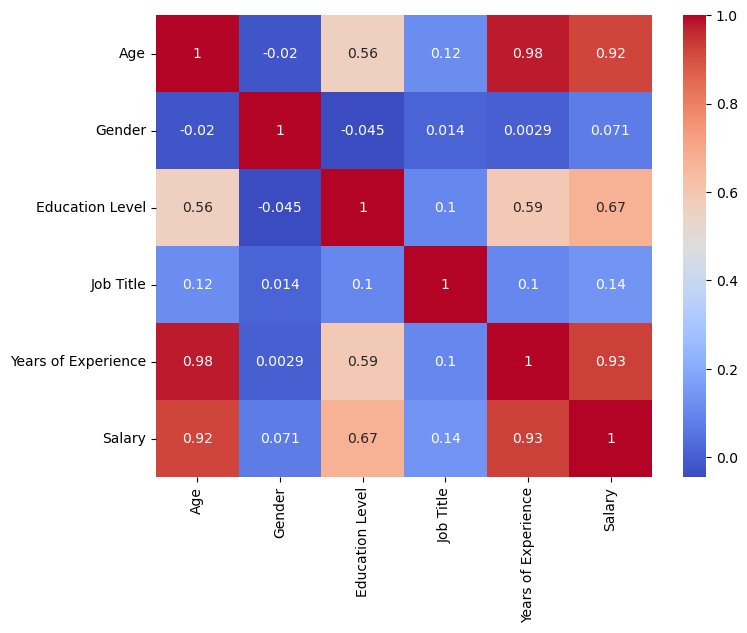

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
X = df.drop("Salary", axis=1)
y = df["Salary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pred = model.predict(X_test)

In [24]:
y_pred

array([168322.70208499,  92742.540874  , 130542.04037052,  84925.67694712,
       163000.86210273, 161155.38806074, 156138.51440344, 105793.26144693,
        57409.49529685, 101741.99731019, 144073.85178206, 158908.07138787,
        37820.75757476,  89067.19813218, 128024.66168136,  57409.49529685,
        69433.08785781,  49496.5789035 ,  79504.26580417,  99256.1219581 ,
       132487.08557319, 108900.28520809, 166754.7439236 ,  60830.63096366,
        84925.67694712,  48472.2634689 , 175220.61715612,  44358.06559525,
       120787.29410742, 147198.05013557,  43864.35225528, 126562.14943456,
        54926.31178769, 154052.62143417,  90582.78639469,  17212.71603859,
       185129.99632171,  50849.16946863, 158579.79625734,  58714.38878856,
        44060.51474771,  93675.77240898, 166518.42056961, 163957.15751092,
        42787.12459309, 158083.55960611, 125221.68857101,  55115.97146503,
        49197.66060767,  34889.57034123, 153642.94986182,  80439.52611889,
       126950.78892527, 1

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.8857407952450549
MAE: 11647.136609116473


In [26]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [27]:
y_pred_dt = dt.predict(X_test)

In [28]:
print("R2 Score:", r2_score(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))

R2 Score: 0.840891058211837
MAE: 11126.209677419354


In [29]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred_rf = rf.predict(X_test)

In [31]:
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

R2 Score: 0.8979941272512536
MAE: 10197.983870967742


In [32]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [33]:
y_pred_gb = gb.predict(X_test)

In [34]:
print("R2 Score:", r2_score(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))

R2 Score: 0.8939610169272215
MAE: 10241.769447417084


In [35]:
df["Predicted Salary"] = rf.predict(X)

In [36]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Predicted Salary
0,32.0,1,0,159,5.0,90000.0,62600.0
1,28.0,0,1,17,3.0,65000.0,66150.0
2,45.0,1,2,130,15.0,150000.0,150200.0
3,36.0,0,0,101,7.0,60000.0,71650.0
4,52.0,1,1,22,20.0,200000.0,194100.0


In [37]:
df.to_csv("salary_prediction_results.csv", index=False)

In [43]:
mapping_df = pd.DataFrame({
    "Job Title": le_job.classes_,
    "Job_Title_Encoded": range(len(le_job.classes_))
})

print(mapping_df.head())

                      Job Title  Job_Title_Encoded
0               Account Manager                  0
1                    Accountant                  1
2      Administrative Assistant                  2
3              Business Analyst                  3
4  Business Development Manager                  4


In [44]:
mapping_df.to_csv("job_title_mapping.csv", index=False)